# Loan Approval Classification

**Author:** Tajamul Khan  
**Task:** Classification  
**Primary metric:** Macro F1

## Project introduction

Classify loan approval from applicant, income, loan and credit-history attributes.

This notebook is designed as a reproducible learning project: it keeps the final holdout untouched, fits every preprocessing step inside a Scikit-learn pipeline, and calculates all reported results from the available data.

## 1. Imports and reproducibility

A fixed seed makes the split and compatible estimators reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, classification_report, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
CLASS_WEIGHT = None

## 2. Load the dataset

Paths are project-relative. If the dataset is not committed, the error message points to the recorded source and exact expected filename.

In [2]:
DATA_FILE = 'loan-train.csv'
PROJECT_FOLDER = 'Loan Approval Prediction using Classification Algorithms'
DATA_SOURCE = 'Training and scoring files are included in this project.'

def resolve_data_path(filename):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "Supervised Learning Projects" / PROJECT_FOLDER / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{filename} was not found. Place it beside the notebook. Dataset information: {DATA_SOURCE}"
    )

DATA_PATH = resolve_data_path(DATA_FILE)
raw = pd.read_csv(DATA_PATH, sep=',', low_memory=False)
print(f"Loaded {DATA_PATH.name}: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

Loaded loan-train.csv: 614 rows × 13 columns


## 3. Data cleaning

The cleaning function removes only documented identifiers, normalises missing-value markers, and leaves all trainable transformations to the pipeline.

In [3]:
def prepare_frame(frame):
    data = frame.copy()
    data.columns = data.columns.astype(str).str.strip()
    data = data.replace({"?": np.nan, "_": np.nan, "": np.nan, "NA": np.nan, "N/A": np.nan})
    data = data.drop_duplicates().reset_index(drop=True)
    removable = [column for column in ['Loan_ID'] if column in data.columns]
    data = data.drop(columns=removable)
    return data.reset_index(drop=True)

data = prepare_frame(raw)
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 4. Data understanding and focused EDA

Inspect shape, types, missingness, duplicates and the target before modelling.

In [4]:
overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_%": (data.isna().mean() * 100).round(2),
    "unique": data.nunique(dropna=False),
})
display(data.head())
display(overview.sort_values("missing", ascending=False).head(15))
print(f"Rows: {len(data):,} | Columns: {data.shape[1]} | Duplicate rows: {data.duplicated().sum():,}")

Rows: 614 | Columns: 12 | Duplicate rows: 0


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,dtype,missing,missing_%,unique
Credit_History,float64,50,8.14,3
Self_Employed,object,32,5.21,3
LoanAmount,float64,22,3.58,204
Dependents,object,15,2.44,5
Loan_Amount_Term,float64,14,2.28,11
Gender,object,13,2.12,3
Married,object,3,0.49,3
Education,object,0,0.00,2
CoapplicantIncome,float64,0,0.00,287
ApplicantIncome,int64,0,0.00,505


,count
Loan_Status,
Y,422
N,192


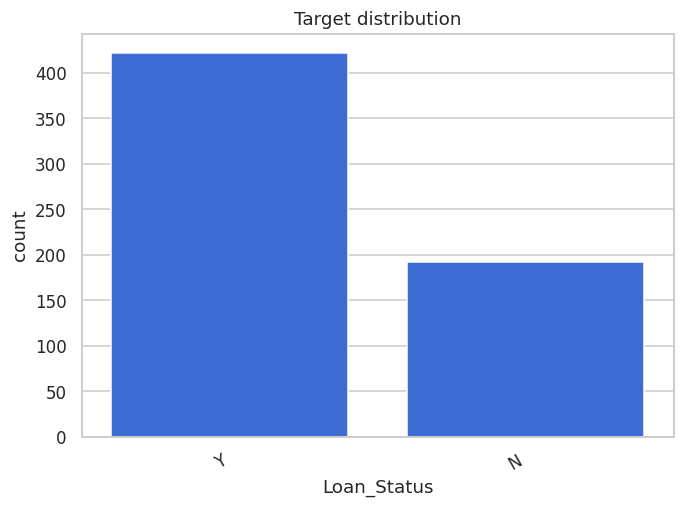

In [5]:
target_order = data['Loan_Status'].value_counts().index
sns.countplot(data=data, x='Loan_Status', order=target_order, color="#2563eb")
plt.title("Target distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
display(data['Loan_Status'].value_counts(dropna=False).rename("count").to_frame())

## 5. Train/holdout strategy

The holdout is created before any imputer, scaler or encoder is fitted.

In [6]:
data = data.dropna(subset=['Loan_Status']).copy()
X = data.drop(columns='Loan_Status')
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training rows: {len(X_train):,} | Holdout rows: {len(X_test):,}")

Training rows: 491 | Holdout rows: 123


## 6. Leakage-safe preprocessing

Numeric columns are median-imputed and scaled. Categorical columns are imputed and one-hot encoded with unknown-category handling.

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, selector(dtype_include=np.number)),
    ("categorical", categorical_pipeline, selector(dtype_exclude=np.number)),
])

## 7. Baseline and model comparison

Cross-validation is performed only on the training partition. The dummy baseline establishes whether the learned models add useful signal.

In [8]:
CLASS_WEIGHT = None
baseline = DummyClassifier(strategy='prior', random_state=RANDOM_STATE)
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=160, min_samples_leaf=2, class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE, n_jobs=1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, estimator in {"Dummy baseline": baseline, **models}.items():
    candidate = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1, error_score="raise")
    rows.append({"Model": name, 'CV macro F1': scores['test_score'].mean(), "CV std": scores["test_score"].std()})

comparison = pd.DataFrame(rows).sort_values('CV macro F1', ascending=False).reset_index(drop=True)
display(comparison.round(4))

eligible = comparison[comparison["Model"] != "Dummy baseline"]
best_name = eligible.iloc[0]["Model"]
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])])
best_pipeline.fit(X_train, y_train)
print(f"Selected model: {best_name}")

Selected model: Logistic Regression


,Model,CV macro F1,CV std
0,Logistic Regression,0.7070,0.0766
1,Random Forest,0.6950,0.0736
2,Decision Tree,0.6661,0.0398
3,Dummy baseline,0.4070,0.0014


## 8. Holdout evaluation

These metrics are calculated once, after model selection, on data the pipeline has not seen.

Holdout accuracy: 0.8618
Holdout macro F1: 0.8147


,precision,recall,f1-score,support
N,0.9565,0.5789,0.7213,38.0000
Y,0.8400,0.9882,0.9081,85.0000
accuracy,0.8618,0.8618,0.8618,0.8618
macro avg,0.8983,0.7836,0.8147,123.0000
weighted avg,0.8760,0.8618,0.8504,123.0000


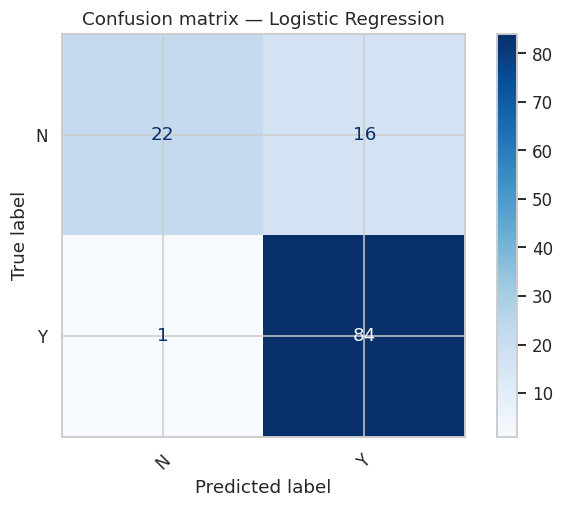

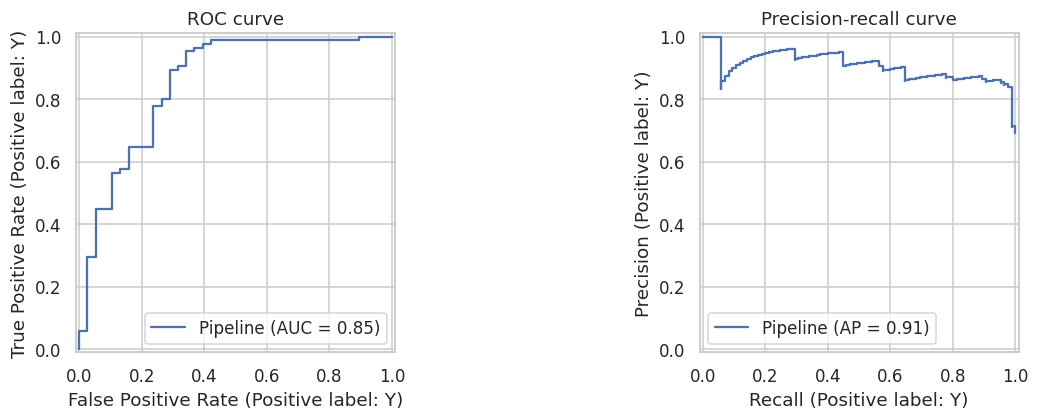

In [9]:
predictions = best_pipeline.predict(X_test)
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

if y_test.nunique() == 2 and (hasattr(best_pipeline, "predict_proba") or hasattr(best_pipeline, "decision_function")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
    axes[0].set_title("ROC curve")
    axes[1].set_title("Precision-recall curve")
    plt.tight_layout()
    plt.show()

## 9. Model interpretation

Permutation importance measures the holdout-score change when each original feature is shuffled. It works across mixed numeric and categorical pipelines.

,feature,importance_mean,importance_std
9,Credit_History,0.3096,0.0120
6,CoapplicantIncome,0.0183,0.0043
0,Gender,0.0000,0.0000
2,Dependents,0.0000,0.0000
1,Married,0.0000,0.0000
4,Self_Employed,0.0000,0.0000
3,Education,0.0000,0.0000
5,ApplicantIncome,0.0000,0.0000
7,LoanAmount,0.0000,0.0000
8,Loan_Amount_Term,0.0000,0.0000


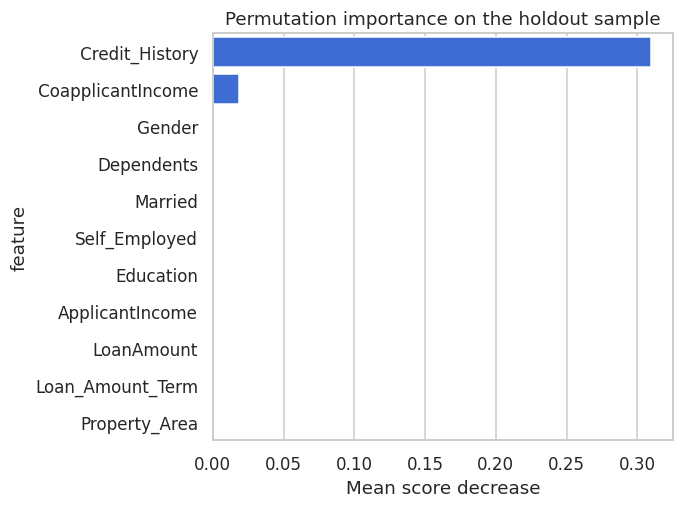

In [10]:
sample_size = min(2000, len(X_test))
X_importance = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_importance = y_test.loc[X_importance.index]
importance = permutation_importance(
    best_pipeline, X_importance, y_importance,
    scoring='f1_macro', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False).head(15)
display(importance_df.round(4))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#2563eb")
plt.title("Permutation importance on the holdout sample")
plt.xlabel("Mean score decrease")
plt.tight_layout()
plt.show()

## 10. Key findings and next steps

- Read the model-comparison table relative to the dummy baseline, not in isolation.
- Use the holdout confusion matrix or residual plot to identify the most costly errors.
- Treat permutation importance as model-specific evidence, not causation.
- Before deployment, validate on a newer or independently collected dataset and monitor data drift.

All numeric results in this notebook are generated from the dataset at execution time; none are hard-coded.